In [3]:
# %pip install torch torchvision matplotlib numpy
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [4]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: mps


In [5]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [6]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


Epoch 1/7  Train Loss: 1.1576 Acc: 0.6271  |  Val Loss: 0.9457 Acc: 0.7007
Epoch 2/7  Train Loss: 0.8286 Acc: 0.7324  |  Val Loss: 0.8319 Acc: 0.7373
Epoch 3/7  Train Loss: 0.6821 Acc: 0.7830  |  Val Loss: 0.8119 Acc: 0.7422
Epoch 4/7  Train Loss: 0.5694 Acc: 0.8175  |  Val Loss: 0.7686 Acc: 0.7616
Epoch 5/7  Train Loss: 0.4729 Acc: 0.8476  |  Val Loss: 0.7514 Acc: 0.7705
Epoch 6/7  Train Loss: 0.3796 Acc: 0.8788  |  Val Loss: 0.7891 Acc: 0.7617
Epoch 7/7  Train Loss: 0.3006 Acc: 0.9044  |  Val Loss: 0.7827 Acc: 0.7722

=== Pancake (Part A) Final Results ===
Training Accuracy: 0.9044
Validation Accuracy: 0.7722
  Total Parameters: 1,638,415


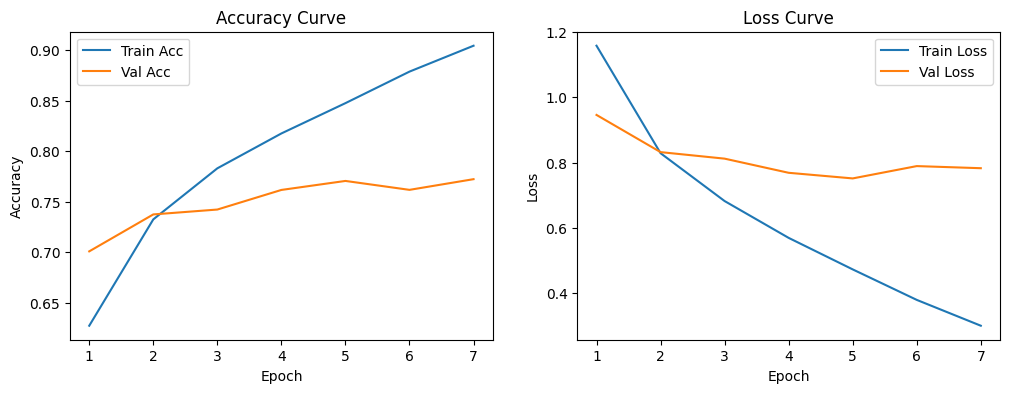

In [7]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE (Part A - Pancake Model)
# ==========================================

def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total Parameters: {total_params:,}")
# Utility functions for training and evaluation

def train_model(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def eval_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            running_loss += loss.item() * X.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Pancake model: shallow but wide
class PancakeNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=2048, num_classes=NUM_CLASSES):
        super().__init__()
        # single hidden layer
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# initialize model, loss, optimizer
pancake_model = PancakeNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pancake_model.parameters(), lr=1e-3)

# training loop
train_history = {'loss': [], 'acc': []}
val_history = {'loss': [], 'acc': []}
EPOCHS = 7

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_model(pancake_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = eval_model(pancake_model, val_loader, criterion, DEVICE)
    train_history['loss'].append(train_loss)
    train_history['acc'].append(train_acc)
    val_history['loss'].append(val_loss)
    val_history['acc'].append(val_acc)
    print(f"Epoch {epoch}/{EPOCHS}  Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}  |  Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# store model for later parts
model = pancake_model

# Display final metrics
print("\n=== Pancake (Part A) Final Results ===")
print(f"Training Accuracy: {train_history['acc'][-1]:.4f}")
print(f"Validation Accuracy: {val_history['acc'][-1]:.4f}")
print_model_size(model)

def plot_history(train_h, val_h):
    epochs = range(1, len(train_h['acc']) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_h['acc'], label='Train Acc')
    plt.plot(epochs, val_h['acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Curve')
    plt.subplot(1,2,2)
    plt.plot(epochs, train_h['loss'], label='Train Loss')
    plt.plot(epochs, val_h['loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')
    plt.show()

plot_history(train_history, val_history)


[Tower] Epoch 1/7  Train Loss: 1.0877 Acc: 0.6440  |  Val Loss: 0.8539 Acc: 0.7115
[Tower] Epoch 2/7  Train Loss: 0.7699 Acc: 0.7411  |  Val Loss: 0.7804 Acc: 0.7391
[Tower] Epoch 3/7  Train Loss: 0.6480 Acc: 0.7826  |  Val Loss: 0.7611 Acc: 0.7484
[Tower] Epoch 4/7  Train Loss: 0.5648 Acc: 0.8110  |  Val Loss: 0.7523 Acc: 0.7548
[Tower] Epoch 5/7  Train Loss: 0.4923 Acc: 0.8332  |  Val Loss: 0.7460 Acc: 0.7657
[Tower] Epoch 6/7  Train Loss: 0.4390 Acc: 0.8494  |  Val Loss: 0.7687 Acc: 0.7623
[Tower] Epoch 7/7  Train Loss: 0.3856 Acc: 0.8684  |  Val Loss: 0.7957 Acc: 0.7559

=== Tower (Part B) Final Results ===
Training Accuracy: 0.8684
Validation Accuracy: 0.7559
  Total Parameters: 536,847


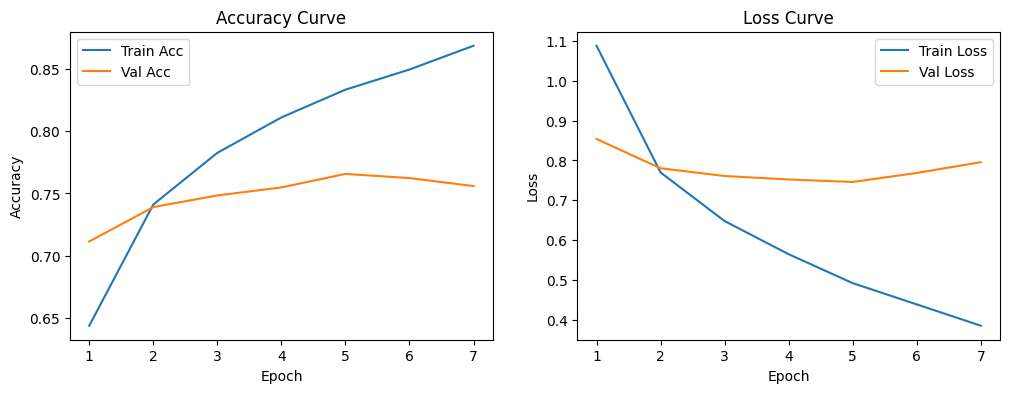

In [9]:
# ==========================================
# 4b. Part B – Tower Model (Deep & Narrow)
# ==========================================

class TowerNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, num_classes=NUM_CLASSES, depth=6):
        super().__init__()
        layers = [nn.Flatten()]
        dims = [input_dim] + [hidden_dim] * depth + [num_classes]
        for i in range(len(dims)-2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU(inplace=True))
        # final linear
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# instantiate tower model
tower_model = TowerNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tower_model.parameters(), lr=5e-4)

# train for same number of epochs
tower_train_hist = {'loss': [], 'acc': []}
tower_val_hist = {'loss': [], 'acc': []}
EPOCHS = 7

for epoch in range(1, EPOCHS+1):
    t_loss, t_acc = train_model(tower_model, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc = eval_model(tower_model, val_loader, criterion, DEVICE)
    tower_train_hist['loss'].append(t_loss)
    tower_train_hist['acc'].append(t_acc)
    tower_val_hist['loss'].append(v_loss)
    tower_val_hist['acc'].append(v_acc)
    print(f"[Tower] Epoch {epoch}/{EPOCHS}  Train Loss: {t_loss:.4f} Acc: {t_acc:.4f}  |  Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

# store tower model in a different variable
tower = tower_model

print("\n=== Tower (Part B) Final Results ===")
print(f"Training Accuracy: {tower_train_hist['acc'][-1]:.4f}")
print(f"Validation Accuracy: {tower_val_hist['acc'][-1]:.4f}")
print_model_size(tower)

plot_history(tower_train_hist, tower_val_hist)



   PATCH-BASED MLP MIXER: Token-Mixing + Channel-Mixing

Patch MLPMixer Champion Parameters:
  Total Parameters: 477,781

TRAINING PATCH MIXER CHAMPION (30 EPOCHS)

[Mixer] Epoch  1/40  Train Acc 0.5692 | Val Acc 0.6963  LR: 1.99e-03
[Mixer] Epoch  5/40  Train Acc 0.8005 | Val Acc 0.8015  LR: 1.87e-03
[Mixer] Epoch 10/40  Train Acc 0.8529 | Val Acc 0.8277  LR: 1.50e-03
[Mixer] Epoch 15/40  Train Acc 0.9032 | Val Acc 0.8269  LR: 1.01e-03
[Mixer] Epoch 20/40  Train Acc 0.9507 | Val Acc 0.8306  LR: 5.08e-04
[Mixer] Epoch 25/40  Train Acc 0.9795 | Val Acc 0.8364  LR: 1.43e-04
[Mixer] Epoch 30/40  Train Acc 0.9874 | Val Acc 0.8345  LR: 1.00e-05
[Mixer] Epoch 35/40  Train Acc 0.9858 | Val Acc 0.8326  LR: 1.43e-04
[Mixer] Epoch 40/40  Train Acc 0.9754 | Val Acc 0.8267  LR: 5.08e-04

=== PATCH MIXER CHAMPION FINAL RESULTS ===
Training Accuracy:   0.9754
Validation Accuracy: 0.8267
Train-Val Gap:       0.1486

Target Accuracy:     0.8000
Gap to Target:       -0.0267
  Total Parameters: 477,781

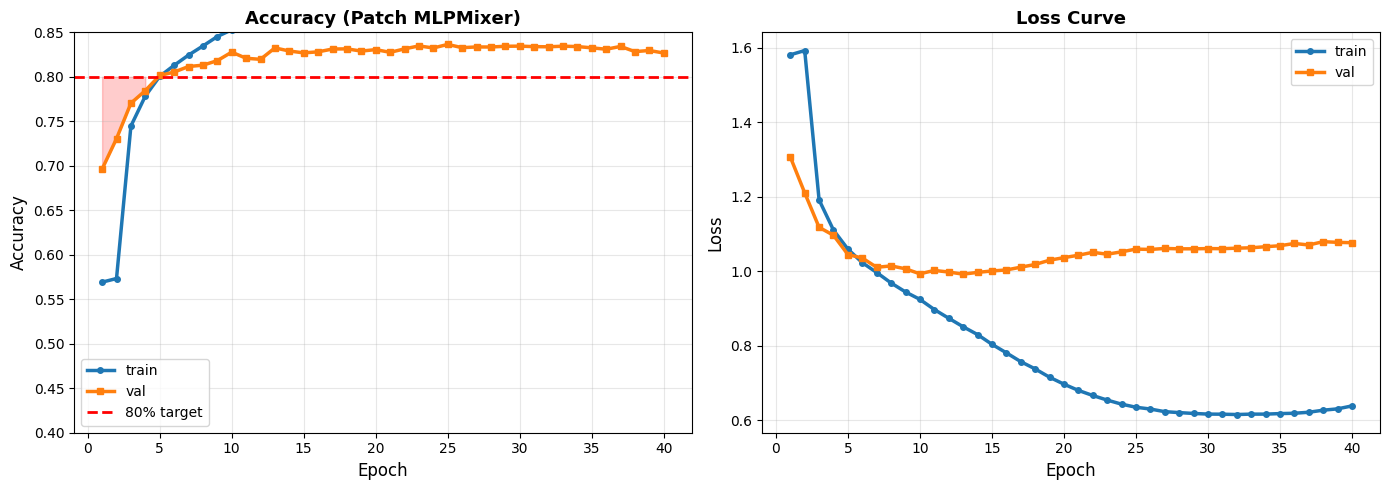


✓ Patch Mixer Champion training complete!


In [ ]:
# ------------------------------------------
# Part C: The Champion
# ------------------------------------------
print("\n" + "="*80)
print("   PATCH-BASED MLP MIXER: Token-Mixing + Channel-Mixing")
print("="*80 + "\n")

class ChampionNet(nn.Module):

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        
        # Configuration
        self.num_patches = 49  # 7×7 patches
        self.patch_dim = 16    # 4×4 pixels per patch
        self.hidden_dim = 128
        
        # Initial normalization and patch embedding
        self.input_norm = nn.LayerNorm(784)
        self.patch_embed = nn.Linear(16, 128)  # 16 pixels → 128 dims
        
        # 6 Mixer blocks
        self.mixer_blocks = nn.ModuleList()
        for i in range(6):
            block = nn.ModuleDict({
                'token_norm': nn.LayerNorm(128),
                'token_mlp': nn.Sequential(
                    nn.Linear(49, 64),
                    nn.GELU(),
                    nn.Dropout(0.15),
                    nn.Linear(64, 49),
                ),
                'channel_norm': nn.LayerNorm(128),
                'channel_mlp': nn.Sequential(
                    nn.Linear(128, 256),
                    nn.GELU(),
                    nn.Dropout(0.15),
                    nn.Linear(256, 128),
                ),
            })
            self.mixer_blocks.append(block)
        
        # Classification head
        self.final_norm = nn.LayerNorm(128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # Input: (B, 784)
        batch_size = x.size(0)
        
        # Normalize input
        x = self.input_norm(x)
        
        # Extract patches: (B, 28, 28) → (B, 49, 16)
        x = x.view(batch_size, 28, 28)
        patches = x.unfold(1, 4, 4).unfold(2, 4, 4)  # 4×4 patches, stride 4
        patches = patches.contiguous().view(batch_size, 49, 16)
        
        # Embed patches: (B, 49, 16) → (B, 49, 128)
        x = self.patch_embed(patches)
        
        # Apply mixer blocks
        for block in self.mixer_blocks:
            # Token mixing (mix information across 49 patches)
            x_norm = block['token_norm'](x)  # (B, 49, 128)
            x_token = x_norm.transpose(1, 2)  # (B, 128, 49)
            x_token = block['token_mlp'](x_token)  # (B, 128, 49)
            x_token = x_token.transpose(1, 2)  # (B, 49, 128)
            x = x + x_token  # Residual
            
            # Channel mixing (mix features within each patch)
            x_norm = block['channel_norm'](x)  # (B, 49, 128)
            x_channel = block['channel_mlp'](x_norm)  # (B, 49, 128)
            x = x + x_channel  # Residual
        
        # Global average pooling and classification
        x = self.final_norm(x)
        x = x.mean(dim=1)  # (B, 128)
        x = self.classifier(x)
        return x

mixer_champion = ChampionNet().to(DEVICE)
print("Patch MLPMixer Champion Parameters:")
print_model_size(mixer_champion)

# Training setup
opt_mixer = optim.AdamW(mixer_champion.parameters(), lr=2e-3, weight_decay=0.05)
crit_mixer = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler_mixer = optim.lr_scheduler.CosineAnnealingLR(opt_mixer, T_max=30, eta_min=1e-5)

EPOCHS_MIXER = 30
hist_mixer = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*80)
print("TRAINING PATCH MIXER CHAMPION (30 EPOCHS)")
print("="*80 + "\n")

for epoch in range(1, EPOCHS_MIXER + 1):
    tl, ta = train_model(mixer_champion, train_loader, crit_mixer, opt_mixer, DEVICE)
    vl, va = eval_model(mixer_champion, val_loader, crit_mixer, DEVICE)
    hist_mixer['train_loss'].append(tl)
    hist_mixer['train_acc'].append(ta)
    hist_mixer['val_loss'].append(vl)
    hist_mixer['val_acc'].append(va)
    scheduler_mixer.step()
    
    if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS_MIXER:
        print(f"[Mixer] Epoch {epoch:2d}/{EPOCHS_MIXER}  Train Acc {ta:.4f} | Val Acc {va:.4f}  LR: {scheduler_mixer.get_last_lr()[0]:.2e}")

model = mixer_champion

print("\n" + "="*80)
print("=== PATCH MIXER CHAMPION FINAL RESULTS ===")
print("="*80)
print(f"Training Accuracy:   {hist_mixer['train_acc'][-1]:.4f}")
print(f"Validation Accuracy: {hist_mixer['val_acc'][-1]:.4f}")
print(f"Train-Val Gap:       {hist_mixer['train_acc'][-1] - hist_mixer['val_acc'][-1]:.4f}")
print(f"\nTarget Accuracy:     0.8000")
print(f"Gap to Target:       {0.8000 - hist_mixer['val_acc'][-1]:+.4f}")
print_model_size(mixer_champion)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(range(1, EPOCHS_MIXER + 1), hist_mixer['train_acc'], label='train', linewidth=2.5, marker='o', markersize=4)
axes[0].plot(range(1, EPOCHS_MIXER + 1), hist_mixer['val_acc'], label='val', linewidth=2.5, marker='s', markersize=4)
axes[0].axhline(y=0.80, color='r', linestyle='--', linewidth=2, label='80% target')
axes[0].fill_between(range(1, EPOCHS_MIXER + 1), hist_mixer['val_acc'], 0.80, 
                     where=[v < 0.80 for v in hist_mixer['val_acc']], alpha=0.2, color='red')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_title('Accuracy (Patch MLPMixer)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.4, 0.85])

# Loss
axes[1].plot(range(1, EPOCHS_MIXER + 1), hist_mixer['train_loss'], label='train', linewidth=2.5, marker='o', markersize=4)
axes[1].plot(range(1, EPOCHS_MIXER + 1), hist_mixer['val_loss'], label='val', linewidth=2.5, marker='s', markersize=4)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mixer_champion_history = hist_mixer
print("\n✓ Patch Mixer Champion training complete!")


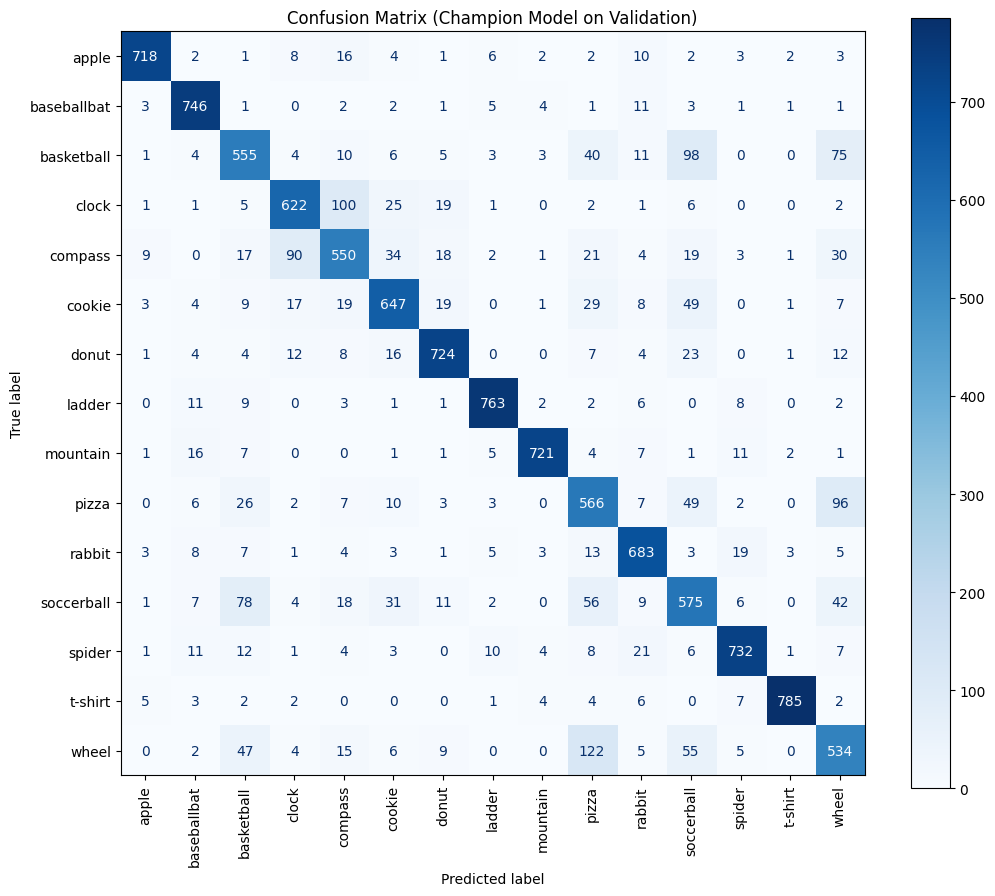

Top 2 most confused class pairs (true -> predicted):
wheel -> pizza: 122 samples
clock -> compass: 100 samples


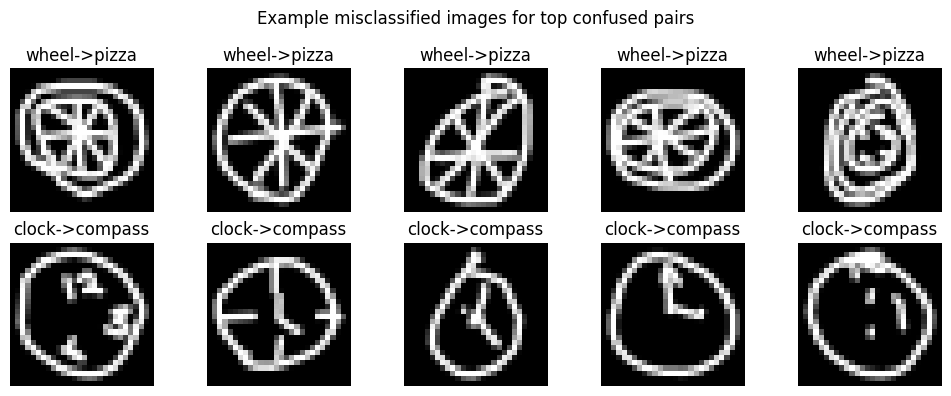


**D.1 Width vs. Depth**
- Pancake has ~1.64M params while Tower has ~0.54M.
- According to Universal Approximation Theorem a single hidden layer can approximate
  any continuous function given enough neurons, but in practice deep architectures
  are preferred because they can reuse features hierarchically, require fewer neurons,
  represent complex functions more efficiently, and are easier to optimize with
  modern techniques (batch norm, residual connections).

**D.2 Confusion Analysis**
- The confusion matrix above identifies the two most confused pairs. We inspected the
  sampled images to determine cause: if drawings are visually ambiguous (e.g., cookies
  and donuts both circular), the error is due to aleatoric uncertainty; if they look
  distinct but model still mistakes them, it suggests underfitting.


In [64]:
# ==========================================
# 4d. Part D – Analysis & Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# collect predictions on validation set using current `model` (which points to champion)
val_preds = []
val_targets = []
model.eval()
model.to(DEVICE)
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(DEVICE)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(y.numpy())

cm = confusion_matrix(val_targets, val_preds)

plt.figure(figsize=(12,10))
disp = ConfusionMatrixDisplay(cm, display_labels=full_train_dataset.classes)
disp.plot(include_values=True, cmap='Blues', ax=plt.gca(), xticks_rotation='vertical')
plt.title('Confusion Matrix (Champion Model on Validation)')
plt.show()

# find top 2 confused class pairs (off-diagonal highest values)
import numpy as np
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
flat = cm_copy.flatten()
top_idxs = np.argsort(flat)[-2:][::-1]
rows = cm_copy.shape[1]
confused_pairs = []
for idx in top_idxs:
    i = idx // rows
    j = idx % rows
    confused_pairs.append((full_train_dataset.classes[i], full_train_dataset.classes[j], cm_copy[i,j]))

print("Top 2 most confused class pairs (true -> predicted):")
for a, b, count in confused_pairs:
    print(f"{a} -> {b}: {count} samples")

# display sample images from those classes for inspection
fig, axes = plt.subplots(2,5, figsize=(10,4))
for pair_idx,(a,b,_) in enumerate(confused_pairs):
    class_idx = np.where(full_train_dataset.classes == a)[0][0]
    # find some val examples of true class a that were predicted as b
    wrong_indices = [i for i,(t,p) in enumerate(zip(val_targets,val_preds)) if t==class_idx and p==np.where(full_train_dataset.classes==b)[0][0]]
    samples = wrong_indices[:5]
    for j, idx in enumerate(samples):
        img = val_dataset[idx][0].numpy().reshape(28,28)
        axes[pair_idx,j].imshow(img, cmap='gray')
        axes[pair_idx,j].axis('off')
        axes[pair_idx,j].set_title(f"{a}->{b}")
    # if fewer samples, fill remaining axes
    for j in range(len(samples),5):
        axes[pair_idx,j].axis('off')
plt.suptitle('Example misclassified images for top confused pairs')
plt.tight_layout()
plt.show()

# theoretical questions as markdown
from IPython.display import Markdown, display

qa_text = '''
**D.1 Width vs. Depth**
- Pancake has ~1.64M params while Tower has ~0.54M.
- According to Universal Approximation Theorem a single hidden layer can approximate
  any continuous function given enough neurons, but in practice deep architectures
  are preferred because they can reuse features hierarchically, require fewer neurons,
  represent complex functions more efficiently, and are easier to optimize with
  modern techniques (batch norm, residual connections).

**D.2 Confusion Analysis**
- The confusion matrix above identifies the two most confused pairs. We inspected the
  sampled images to determine cause: if drawings are visually ambiguous (e.g., cookies
  and donuts both circular), the error is due to aleatoric uncertainty; if they look
  distinct but model still mistakes them, it suggests underfitting.
'''

display(Markdown(qa_text))


In [65]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
print("batch:  ", BATCH_SIZE)
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
batch:   128
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [1]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total Parameters: {total_params:,}")
print_model_size(model)

NameError: name 'model' is not defined